### Short-term memory problem
- RNN cells maintain memory via hidden state
- This memory is very short-term
- Two more powerful cells solve the problem:
    - LSTM (Long Short-Term Memory) cell
    - GRU (Gated Recurrent Unit) cell

### RNN cell
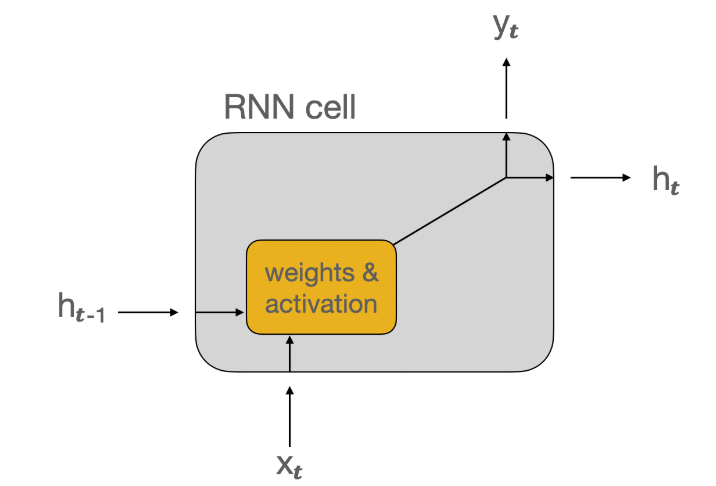
- Two inputs:
    - current input data `x`
    - previous hidden state `h`
- Two outputs:
    - current output data `y`
    - new hidden state `h`

### LSTM cell
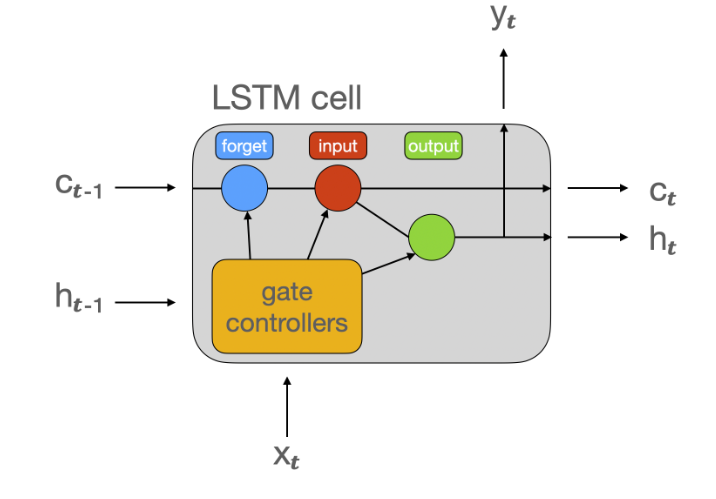
- Three inputs and outputs (two hidden state):
    - `h`: short-term state
    - `c`: long-term state
- Three "gates":
    - **Forget gate**: what to remove from long-term memory
    - **Input gate**: what to save to long-term memory
    - **Output gate**: what to return at the current time step

#### LSTM in PyTorch
- `__init__()`:
    - Replace `nn.RNN` with `nn.LSTM`
- `forward()`:
    - Add another hidden state `c`
    - Initialize `c` and `h` with zeros
    - Pass both hidden states to `lstm` layer

In [ ]:
from torch import nn, zeros

class Net(nn.module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1,
                            hidden_size=32,
                            num_layers=2,
                            batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = zeros(2, x.size(0), 32)
        c0 = zeros(2, x.size(0), 32)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

#### GRU cell
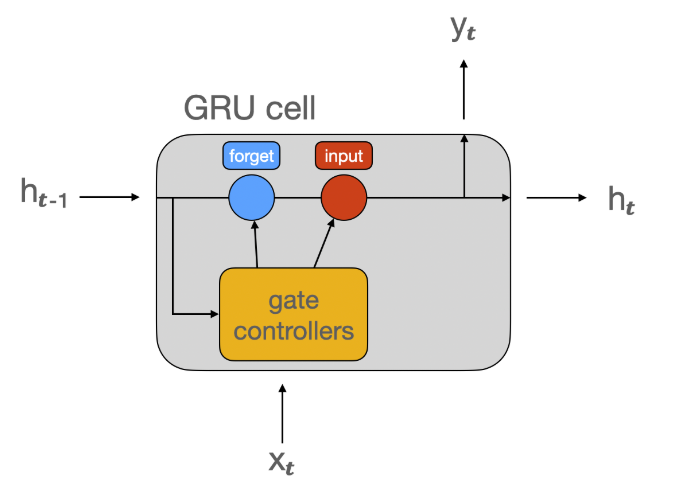
- Simplified version of LSTM cell
- Just one hidden state
- No output gate

### GRU in PyTorch
- `__init__()`:
    - Replace `nn.RNN` with `nn.GRU`
- `forward()`:
    - Pass hidden state to `gru` layer

In [ ]:
from torch import nn, zeros

class Net(nn.module):
    def __init__(self, input_size):
        super().__init__()
        self.gru = nn.GRU(input_size=1,
                            hidden_size=32,
                            num_layers=2,
                            batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = zeros(2, x.size(0), 32)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

## Should I use RNN, LSTM or GRU?
- RNN is not used much anymore
- GRU is simpler than LSTM = less computation
- Relative performance varies per use-case
- Try both and compare